In [19]:
# ============================================
# COMPLETE SPOTIFY SONG RECOMMENDATION SYSTEM
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors 
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# ============================================
# 1. LOAD AND EXPLORE DATA
# ============================================

# Load the data
df = pd.read_csv(r"E:\CLG\MU\FY_2\Machine_Learning\Spotify\spotify.csv")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 5 rows:")
print(df.head())

# Basic info
print("\n" + "="*60)
print("DATA INFORMATION")
print("="*60)
print(df.info())

# Check for missing values
print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
print(df.isnull().sum())

# ============================================
# 2. DATA CLEANING
# ============================================

print("\n" + "="*60)
print("DATA CLEANING")
print("="*60)

# Create a clean copy
df_clean = df.copy()



Dataset shape: (85000, 19)
Columns: ['track_id', 'track_name', 'artist_name', 'album_name', 'release_date', 'genre', 'duration_ms', 'popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'instrumentalness', 'tempo', 'stream_count', 'country', 'explicit', 'label']

First 5 rows:
           track_id              track_name    artist_name         album_name  \
0  TRK-BEBD53DA84E1         Agent every (0)    Noah Rhodes  Beautiful instead   
1  TRK-6A32496762D7           Night respond  Jennifer Cole              Table   
2  TRK-47AA7523463E  Future choice whatever  Brandon Davis      Page southern   
3  TRK-25ADA22E3B06     Bad fall pick those    Corey Jones             Spring   
4  TRK-9245F2AD996A                 Husband      Mark Diaz        Great prove   

  release_date  genre  duration_ms  popularity  danceability  energy  key  \
0   2016-04-01    Pop       234194          55          0.15    0.74    9   
1   2022-04-15  Metal       375706          45          0.44    0.46

Dataset shape after cleaning: (85000, 20)

EXPLORATORY DATA ANALYSIS

Top 10 Genres by count:
genre
Metal        7200
Jazz         7177
Hip-Hop      7160
Classical    7158
Rock         7113
Pop          7096
R&B          7084
Folk         7080
Country      7030
Indie        7007
Name: count, dtype: int64

Top 10 Countries by count:
country
India             8629
Canada            8620
Japan             8582
France            8559
Germany           8551
Brazil            8490
United Kingdom    8458
Australia         8415
United States     8358
Mexico            8338
Name: count, dtype: int64

Statistical Summary of Numerical Features:
         popularity  danceability        energy         tempo  stream_count
count  85000.000000  85000.000000  85000.000000  85000.000000  8.500000e+04
mean      48.162894      0.520710      0.505412    129.948351  2.143547e+05
std       14.829752      0.270799      0.279774     40.444321  1.680637e+06
min        0.000000      0.050000      0.020000     60

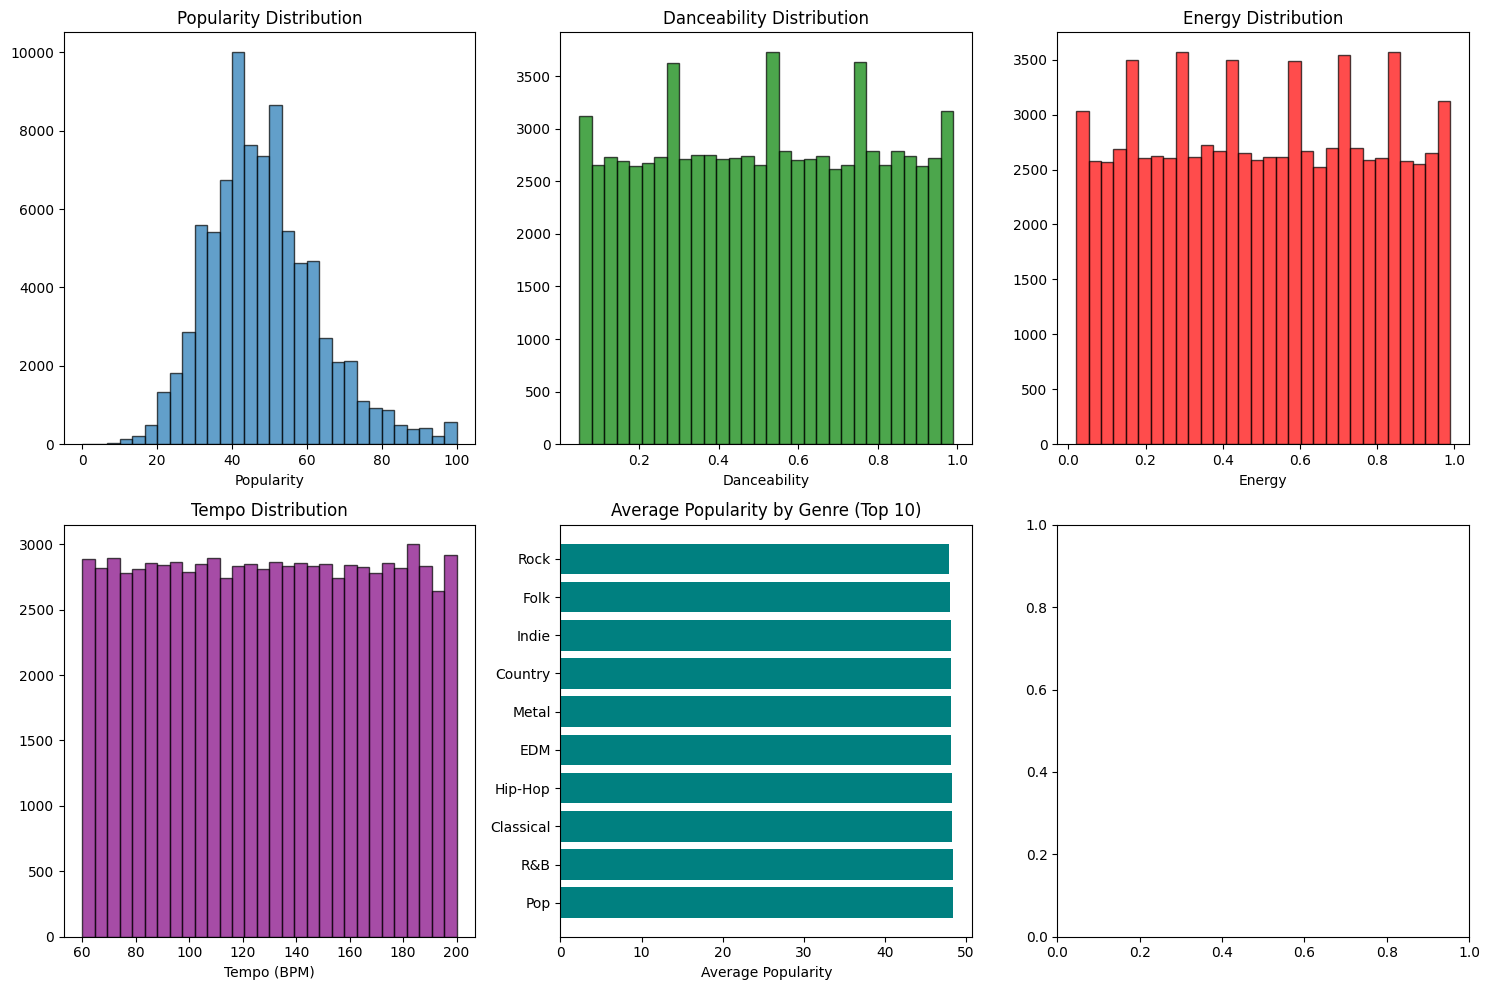

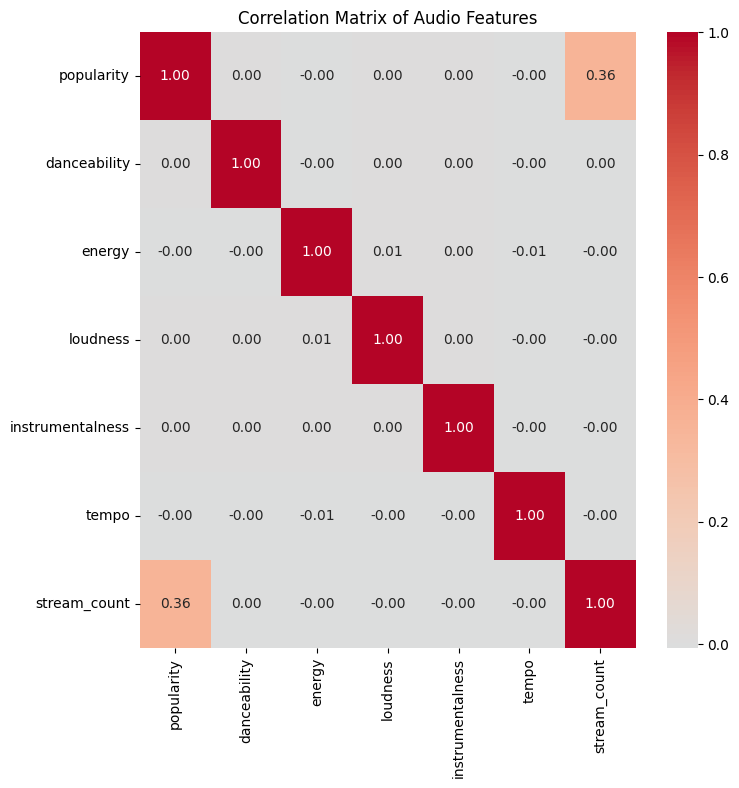

In [2]:
# Handle missing values
df_clean['duration_ms'] = df_clean['duration_ms'].fillna(df_clean['duration_ms'].median())
df_clean['popularity'] = df_clean['popularity'].fillna(df_clean['popularity'].median())
df_clean['stream_count'] = df_clean['stream_count'].fillna(df_clean['stream_count'].median())

# Fill missing audio features with median
audio_features = ['danceability', 'energy', 'loudness', 'instrumentalness', 'tempo']
for col in audio_features:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Handle infinite values and extreme outliers in stream_count
df_clean['stream_count'] = df_clean['stream_count'].replace([np.inf, -np.inf], df_clean['stream_count'].median())
df_clean['log_stream_count'] = np.log1p(df_clean['stream_count'])

print(f"Dataset shape after cleaning: {df_clean.shape}")

# ============================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================

print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# Genre distribution
print("\nTop 10 Genres by count:")
print(df_clean['genre'].value_counts().head(10))

# Country distribution
print("\nTop 10 Countries by count:")
print(df_clean['country'].value_counts().head(10))

# Statistical summary
print("\nStatistical Summary of Numerical Features:")
print(df_clean[['popularity', 'danceability', 'energy', 'tempo', 'stream_count']].describe())

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Popularity distribution
axes[0].hist(df_clean['popularity'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_title('Popularity Distribution')
axes[0].set_xlabel('Popularity')

# Danceability distribution
axes[1].hist(df_clean['danceability'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('Danceability Distribution')
axes[1].set_xlabel('Danceability')

# Energy distribution
axes[2].hist(df_clean['energy'], bins=30, edgecolor='black', alpha=0.7, color='red')
axes[2].set_title('Energy Distribution')
axes[2].set_xlabel('Energy')

# Tempo distribution
axes[3].hist(df_clean['tempo'], bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[3].set_title('Tempo Distribution')
axes[3].set_xlabel('Tempo (BPM)')

# Genre popularity
genre_pop = df_clean.groupby('genre')['popularity'].mean().sort_values(ascending=False).head(10)
axes[4].barh(genre_pop.index, genre_pop.values, color='teal')
axes[4].set_title('Average Popularity by Genre (Top 10)')
axes[4].set_xlabel('Average Popularity')

plt.tight_layout()
plt.show()

# Correlation matrix
plt.figure(figsize=(8, 8))
numerical_cols = ['popularity', 'danceability', 'energy', 'loudness', 'instrumentalness', 'tempo', 'stream_count']
corr_matrix = df_clean[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Audio Features')
plt.show()



FEATURE ENGINEERING
Selected features for recommendation: ['danceability', 'energy', 'loudness', 'instrumentalness', 'tempo', 'popularity']
Features scaled successfully!

PCA Explained Variance Ratio: [0.16886037 0.1676865 ]
Total variance explained: 33.65%


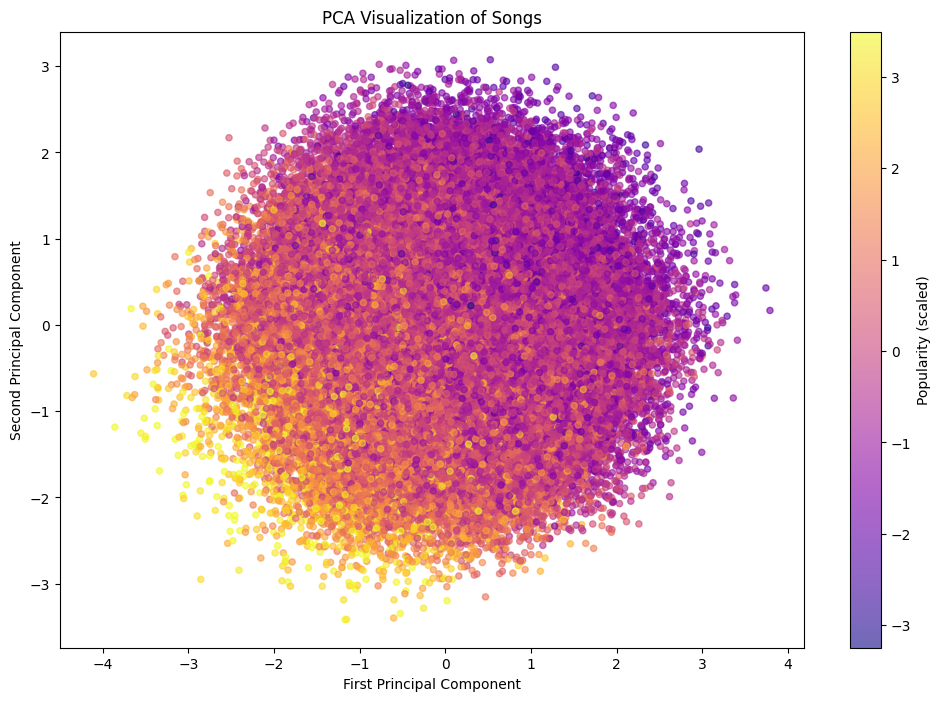

In [3]:
# ============================================
# 4. FEATURE ENGINEERING
# ============================================

print("\n" + "="*60)
print("FEATURE ENGINEERING")
print("="*60)

# Create additional features
df_clean['duration_min'] = df_clean['duration_ms'] / 60000
df_clean['energy_dance_ratio'] = df_clean['energy'] / (df_clean['danceability'] + 0.01)

# Select features for recommendation
content_features = ['danceability', 'energy', 'loudness', 'instrumentalness', 'tempo', 'popularity']

print(f"Selected features for recommendation: {content_features}")

# Scale the features
scaler = StandardScaler()
df_clean[content_features] = scaler.fit_transform(df_clean[content_features])

print("Features scaled successfully!")

# ============================================
# 5. DIMENSIONALITY REDUCTION (PCA)
# ============================================

# Apply PCA for visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_clean[content_features])

df_clean['pca_1'] = pca_result[:, 0]
df_clean['pca_2'] = pca_result[:, 1]

print(f"\nPCA Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

# Visualize PCA
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df_clean['pca_1'], df_clean['pca_2'], 
                      c=df_clean['popularity'], cmap='plasma', 
                      alpha=0.6, s=20)
plt.colorbar(scatter, label='Popularity (scaled)')
plt.title('PCA Visualization of Songs')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.show()



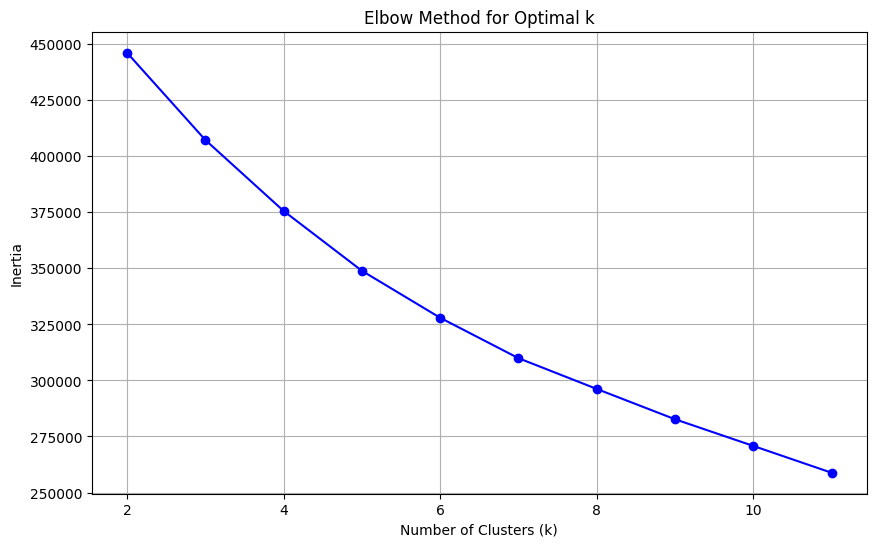

In [4]:
# ============================================
# 6. CLUSTERING ANALYSIS
# ============================================

# Find optimal number of clusters
inertias = []
K_range = range(2, 12)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_clean[content_features])
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()




Cluster Analysis:
         danceability  energy  popularity  track_id
cluster                                            
0               0.048  -0.008       1.778     11106
1               0.136   0.056      -0.286     18291
2               0.964  -0.050      -0.266     18470
3              -0.176  -0.050      -0.265     18662
4              -0.949   0.050      -0.253     18471


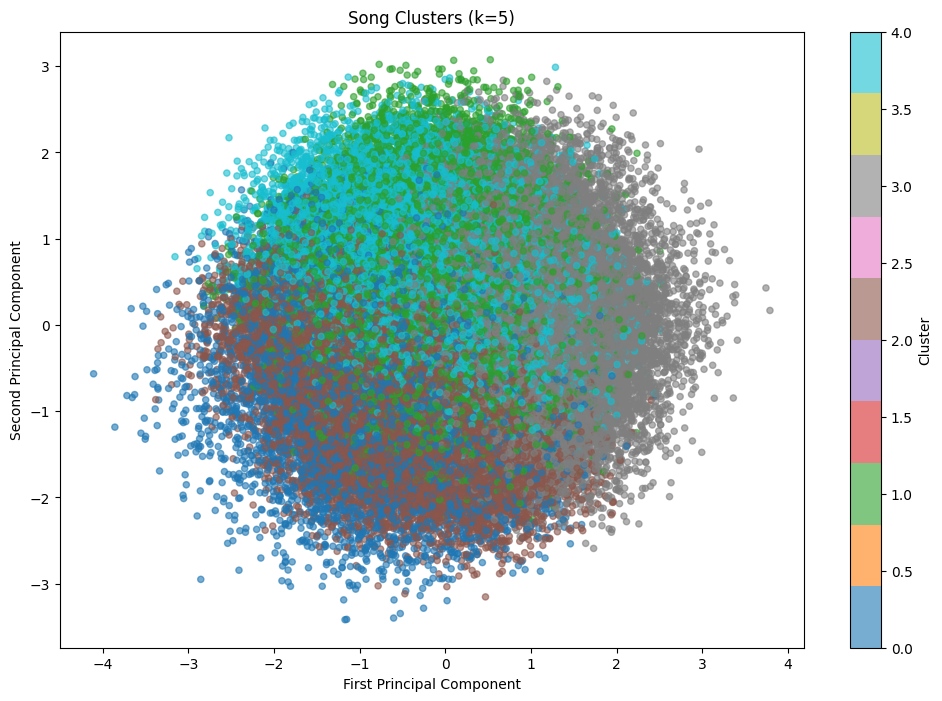

In [5]:
# Apply K-Means with k=5
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clean['cluster'] = kmeans.fit_predict(df_clean[content_features])

# Analyze clusters
print("\nCluster Analysis:")
cluster_summary = df_clean.groupby('cluster').agg({
    'danceability': 'mean',
    'energy': 'mean', 
    'popularity': 'mean',
    'track_id': 'count'
}).round(3)
print(cluster_summary)

# Visualize clusters
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df_clean['pca_1'], df_clean['pca_2'], 
                      c=df_clean['cluster'], cmap='tab10', 
                      alpha=0.6, s=20)
plt.colorbar(scatter, label='Cluster')
plt.title(f'Song Clusters (k={optimal_k})')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.show()



In [6]:
# ============================================
# 7. RECOMMENDATION SYSTEM CLASSES
# ============================================

class ContentBasedRecommender:
    """Recommend songs based on audio feature similarity"""
    
    def __init__(self, df, features):
        self.df = df.reset_index(drop=True)
        self.features = features
        self.feature_matrix = df[features].values

    def recommend_by_track_id(self, track_id, n_recommendations=10):
        """Recommend songs similar to a given track"""
        idx = self.df[self.df['track_id'] == track_id].index
        if len(idx) == 0:
            return f"Track ID {track_id} not found"
        idx = idx[0]
        
        # Calculate cosine similarity
        track_features = self.feature_matrix[idx].reshape(1, -1)
        similarities = cosine_similarity(track_features, self.feature_matrix)[0]
        
        # Get top similar songs (excluding itself)
        similar_indices = similarities.argsort()[::-1][1:n_recommendations+1]
        
        recommendations = self.df.iloc[similar_indices][
            ['track_name', 'artist_name', 'genre', 'popularity']
        ].copy()
        recommendations['similarity_score'] = similarities[similar_indices]
        
        return recommendations

    def recommend_by_track_id(self, track_id, n_recommendations=10):
        """Recommend songs similar to a given track"""
        idx = self.df[self.df['track_id'] == track_id].index
        if len(idx) == 0:
            return f"Track ID {track_id} not found"
        idx = idx[0]
        
        # Calculate cosine similarity
        track_features = self.feature_matrix[idx].reshape(1, -1)
        similarities = cosine_similarity(track_features, self.feature_matrix)[0]
        
        # Get top similar songs (excluding itself)
        similar_indices = similarities.argsort()[::-1][1:n_recommendations+1]
        
        recommendations = self.df.iloc[similar_indices][
            ['track_name', 'artist_name', 'genre', 'popularity']
        ].copy()
        recommendations['similarity_score'] = similarities[similar_indices]
        
        return recommendations
        
    
    def recommend_by_track_name(self, track_name, n_recommendations=10):
        """Recommend songs similar to a given track name"""
        track = self.df[self.df['track_name'].str.lower() == track_name.lower()]
        if len(track) == 0:
            # Try partial match
            track = self.df[self.df['track_name'].str.lower().str.contains(track_name.lower())]
            if len(track) == 0:
                return f"Track '{track_name}' not found"

class HybridRecommender:
    """Hybrid recommender combining content similarity and popularity"""
    
    def __init__(self, df, features, content_weight=0.6, popularity_weight=0.4):
        self.df = df.reset_index(drop=True)
        self.features = features
        self.content_weight = content_weight
        self.popularity_weight = popularity_weight
        self.feature_matrix = df[features].values
        
        # Normalize popularity scores to [0, 1]
        self.popularity_scores = df['popularity'].values
        self.popularity_scores_normalized = (self.popularity_scores - self.popularity_scores.min()) / \
                                             (self.popularity_scores.max() - self.popularity_scores.min() + 1e-8)
        

    def recommend_by_track_id(self, track_id, n_recommendations=10):
        """Hybrid recommendation combining content and popularity"""
        idx = self.df[self.df['track_id'] == track_id].index
        if len(idx) == 0:
            return f"Track ID {track_id} not found"
        idx = idx[0]
        
        # Content similarity
        track_features = self.feature_matrix[idx].reshape(1, -1)
        content_similarities = cosine_similarity(track_features, self.feature_matrix)[0]
        
        # Combine scores
        hybrid_scores = (self.content_weight * content_similarities + 
                        self.popularity_weight * self.popularity_scores_normalized)
        
        # Exclude the query track
        hybrid_scores[idx] = -1
        
        # Get top recommendations
        similar_indices = hybrid_scores.argsort()[::-1][:n_recommendations]
        
        recommendations = self.df.iloc[similar_indices][
            ['track_name', 'artist_name', 'genre', 'popularity']
        ].copy()
        recommendations['hybrid_score'] = hybrid_scores[similar_indices]
        
        return recommendations

    def recommend_by_track_name(self, track_name, n_recommendations=10):
        """Recommend using track name"""
        track = self.df[self.df['track_name'].str.lower() == track_name.lower()]
        if len(track) == 0:
            track = self.df[self.df['track_name'].str.lower().str.contains(track_name.lower())]
            if len(track) == 0:
                return f"Track '{track_name}' not found"
        
        return self.recommend_by_track_id(track.iloc[0]['track_id'], n_recommendations)


class KNNRecommender:
    """K-Nearest Neighbors based recommender"""
    
    def __init__(self, df, features, n_neighbors=20):
        self.df = df.reset_index(drop=True)
        self.features = features
        self.knn = NearestNeighbors(n_neighbors=n_neighbors, metric='cosine')
        self.knn.fit(df[features].values)

    def recommend_by_track_id(self, track_id, n_recommendations=10):
        """Recommend using KNN"""
        idx = self.df[self.df['track_id'] == track_id].index
        if len(idx) == 0:
            return f"Track ID {track_id} not found"
        idx = idx[0]
        
        distances, indices = self.knn.kneighbors(
            self.df.iloc[idx][self.features].values.reshape(1, -1),
            n_neighbors=n_recommendations + 1
        )
        
        # Exclude the query track
        indices = indices.flatten()[1:]
        distances = distances.flatten()[1:]
        
        recommendations = self.df.iloc[indices][
            ['track_name', 'artist_name', 'genre', 'popularity']
        ].copy()
        recommendations['distance'] = distances
        
        return recommendations
    
    def recommend_by_track_name(self, track_name, n_recommendations=10):
        """Recommend using track name"""
        track = self.df[self.df['track_name'].str.lower() == track_name.lower()]
        if len(track) == 0:
            track = self.df[self.df['track_name'].str.lower().str.contains(track_name.lower())]
            if len(track) == 0:
                return f"Track '{track_name}' not found"
        
        return self.recommend_by_track_id(track.iloc[0]['track_id'], n_recommendations)


class GenreRecommender:
    """Recommend popular songs from specific genres"""
    
    def __init__(self, df):
        self.df = df
        
    def recommend_by_genre(self, genre, n_recommendations=10):
        """Recommend popular songs from a genre"""
        genre_songs = self.df[self.df['genre'].str.lower() == genre.lower()]
        
        if len(genre_songs) == 0:
            # Try partial match
            genre_songs = self.df[self.df['genre'].str.lower().str.contains(genre.lower())]
            if len(genre_songs) == 0:
                return f"Genre '{genre}' not found"
        
        return genre_songs.sort_values('popularity', ascending=False)[
            ['track_name', 'artist_name', 'genre', 'popularity']
        ].head(n_recommendations)


class ArtistRecommender:
    """Recommend songs by specific artists"""
    
    def __init__(self, df):
        self.df = df
        
    def recommend_by_artist(self, artist_name, n_recommendations=10):
        """Recommend popular songs by an artist"""
        artist_songs = self.df[self.df['artist_name'].str.lower() == artist_name.lower()]
        
        if len(artist_songs) == 0:
            # Try partial match
            artist_songs = self.df[self.df['artist_name'].str.lower().str.contains(artist_name.lower())]
            if len(artist_songs) == 0:
                return f"Artist '{artist_name}' not found"
        
        return artist_songs.sort_values('popularity', ascending=False)[
            ['track_name', 'artist_name', 'genre', 'popularity']
        ].head(n_recommendations)



In [7]:
# ============================================
# 8. INITIALIZE RECOMMENDERS
# ============================================

print("\n" + "="*60)
print("INITIALIZING RECOMMENDATION SYSTEMS")
print("="*60)

# Initialize all recommenders
content_recommender = ContentBasedRecommender(df_clean, content_features)
hybrid_recommender = HybridRecommender(df_clean, content_features)
knn_recommender = KNNRecommender(df_clean, content_features)
genre_recommender = GenreRecommender(df_clean)
artist_recommender = ArtistRecommender(df_clean)

print("All recommenders initialized successfully!")




INITIALIZING RECOMMENDATION SYSTEMS
All recommenders initialized successfully!


In [8]:
# ============================================
# 9. TEST THE RECOMMENDATION SYSTEMS
# ============================================

print("\n" + "="*60)
print("TESTING RECOMMENDATION SYSTEMS")
print("="*60)

# Get a sample track
sample_track = df_clean.iloc[0]
print(f"\nSample Track: '{sample_track['track_name']}' by {sample_track['artist_name']}")
print(f"Genre: {sample_track['genre']}")
print(f"Popularity (scaled): {sample_track['popularity']:.3f}")
print("-" * 60)




TESTING RECOMMENDATION SYSTEMS

Sample Track: 'Agent every (0)' by Noah Rhodes
Genre: Pop
Popularity (scaled): 0.461
------------------------------------------------------------


In [9]:
# Genre-based recommendations
print("\nTop Rock Songs:")
rock_recs = genre_recommender.recommend_by_genre('Rock', 10)
print(rock_recs.to_string())



Top Rock Songs:
                           track_name        artist_name genre  popularity
25597                    Factor owner      Tonya Collins  Rock    3.495501
23413                    Relationship    Christina Brown  Rock    3.495501
27335                Ever large glass       James Chaney  Rock    3.495501
29267       President production both     Justin Sanders  Rock    3.495501
29284                       Nor visit  Elizabeth Stanley  Rock    3.495501
41247                    Act response    Victoria Martin  Rock    3.495501
21244                Positive picture      Lindsey Brown  Rock    3.495501
36470                    When contain         Paul Fritz  Rock    3.495501
40601  Conference read you experience       Amy Shepherd  Rock    3.495501
36375                        For that        Terry Parks  Rock    3.495501


In [10]:
# Artist-based recommendations
print("\n" + "="*60)
print("ARTIST-BASED RECOMMENDATIONS")
print("="*60)

top_artist = df_clean['artist_name'].value_counts().index[0]
print(f"\nTop songs by {top_artist}:")
artist_recs = artist_recommender.recommend_by_artist(top_artist, 10)
print(artist_recs.to_string())


ARTIST-BASED RECOMMENDATIONS

Top songs by Michael Smith:
                           track_name    artist_name      genre  popularity
78546                           White  Michael Smith  Classical    3.023474
69652                     Course well  Michael Smith    Hip-Hop    1.944556
70425          Until despite movement  Michael Smith       Rock    1.607393
51633  Indicate level training public  Michael Smith       Rock    1.607393
4433                       Her person  Michael Smith       Rock    1.539961
17433                 Need difference  Michael Smith        EDM    1.539961
46529                     Group under  Michael Smith       Rock    1.472529
21987                 Bit itself book  Michael Smith        R&B    1.405096
22253                 Common position  Michael Smith        EDM    1.270231
21538                   Must indicate  Michael Smith       Jazz    1.202799


In [11]:
# ============================================
# 11. RECOMMEND BY TRACK NAME (USER FRIENDLY)
# ============================================

print("\n" + "="*60)
print("RECOMMEND BY TRACK NAME")
print("="*60)

# Try a few track names
test_track_names = ['Agent every (0)', 'Night respond', 'Future choice whatever']

for track_name in test_track_names:
    print(f"\n--- Recommendations for '{track_name}' ---")
    recs = hybrid_recommender.recommend_by_track_name(track_name, 5)
    if isinstance(recs, str):
        print(recs)
    else:
        print(recs[['track_name', 'artist_name', 'genre']].to_string())




RECOMMEND BY TRACK NAME

--- Recommendations for 'Agent every (0)' ---
            track_name     artist_name    genre
78423  Your choose win  Pamela Ramirez      R&B
74350    Push daughter   Lauren Steele     Jazz
75020             Make  Laura Sullivan    Metal
43112      News father      Adam Jones     Rock
79104  Air guess court  Scott Santiago  Hip-Hop

--- Recommendations for 'Night respond' ---
          track_name   artist_name      genre
74682           Baby  Marvin Lopez        R&B
41993          Court   Edwin Kelly      Metal
38755  He food treat   Mark Miller  Classical
174       Movie stop  James Jacobs        R&B
64515      Necessary  Ethan Parker  Reggaeton

--- Recommendations for 'Future choice whatever' ---
                     track_name      artist_name    genre
34544              Maybe effect        Jane Cole    Indie
47557  Tell rest avoid probably  Kimberly Bowman      EDM
21702          Democratic scene       Julie Hall  Hip-Hop
49601          Recognize parent  

In [12]:
# ============================================
# 12. COMPLETE RECOMMENDATION FUNCTION
# ============================================

def get_recommendations(query, recommendation_type='hybrid', n_recommendations=10):
    """
    Get song recommendations based on various criteria
    
    Parameters:
    - query: track name, artist name, or genre
    - recommendation_type: 'hybrid', 'content', 'knn', 'genre', 'artist'
    - n_recommendations: number of recommendations to return
    
    Returns:
    - DataFrame with recommendations
    """
    
    if recommendation_type == 'genre':
        return genre_recommender.recommend_by_genre(query, n_recommendations)
    
    elif recommendation_type == 'artist':
        return artist_recommender.recommend_by_artist(query, n_recommendations)
    
    elif recommendation_type == 'content':
        return content_recommender.recommend_by_track_name(query, n_recommendations)
    
    elif recommendation_type == 'knn':
        return knn_recommender.recommend_by_track_name(query, n_recommendations)
    
    elif recommendation_type == 'hybrid':
        return hybrid_recommender.recommend_by_track_name(query, n_recommendations)
    
    else:
        return "Invalid recommendation type. Choose: 'hybrid', 'content', 'knn', 'genre', 'artist'"


In [13]:
# ============================================
# 13. DEMO: GET RECOMMENDATIONS
# ============================================

print("\n" + "="*60)
print("DEMO: GET RECOMMENDATIONS FOR A SONG")
print("="*60)

# Example 1: Get hybrid recommendations
print("\nExample 1: Hybrid recommendations for 'Agent every (0)'")
recommendations = get_recommendations('Agent every (0)', 'hybrid', 8)
if isinstance(recommendations, str):
    print(recommendations)
else:
    print(recommendations.to_string())



DEMO: GET RECOMMENDATIONS FOR A SONG

Example 1: Hybrid recommendations for 'Agent every (0)'
                              track_name      artist_name      genre  popularity  hybrid_score
78423                    Your choose win   Pamela Ramirez        R&B    1.809691      0.852323
74350                      Push daughter    Lauren Steele       Jazz    1.472529      0.842219
75020                               Make   Laura Sullivan      Metal    1.742258      0.836240
43112                        News father       Adam Jones       Rock    2.079420      0.833540
79104                    Air guess court   Scott Santiago    Hip-Hop    1.472529      0.832834
71925               Their play woman new  Patricia Harvey       Folk    1.337664      0.830402
41691  Against without fast attorney lot       Diane Wood       Jazz    1.674826      0.830386
48800                    Usually ever me    Brittany Beck  Classical    1.337664      0.829808


In [14]:
# Example 2: Get genre recommendations
print("\n" + "="*60)
print("Example 2: Popular Pop songs")
pop_recs = get_recommendations('Pop', 'genre', 10)
if isinstance(pop_recs, str):
    print(pop_recs)
else:
    print(pop_recs.to_string())

# Example 3: Get artist recommendations
print("\n" + "="*60)
print("Example 3: Songs by Noah Rhodes")
artist_recs = get_recommendations('Noah Rhodes', 'artist', 5)
if isinstance(artist_recs, str):
    print(artist_recs)
else:
    print(artist_recs.to_string())



Example 2: Popular Pop songs
                        track_name          artist_name genre  popularity
74669                  Growth task         Jeremiah Cox   Pop    3.495501
55765                  Every sport  Alexander Zimmerman   Pop    3.495501
13145          Significant require       Mary Hernandez   Pop    3.495501
48490                 Compare half            Jim Tyler   Pop    3.495501
25433  Black back inside character         Joseph Ramos   Pop    3.495501
36697                         Poor            Roy Gibbs   Pop    3.495501
15997                          Yet      Crystal Jackson   Pop    3.495501
20763                 Explain ever        Michael Lopez   Pop    3.495501
81656                   Major edge        Richard Potts   Pop    3.495501
56324               Chance success       Melissa Murphy   Pop    3.495501

Example 3: Songs by Noah Rhodes
        track_name  artist_name genre  popularity
0  Agent every (0)  Noah Rhodes   Pop    0.461043


In [15]:
# ============================================
# 14. EVALUATION METRICS
# ============================================

print("\n" + "="*60)
print("EVALUATION METRICS")
print("="*60)

def evaluate_recommender(recommender, test_tracks, n_recommendations=10):
    """Evaluate recommender performance"""
    results = []
    
    for track_name in test_tracks:
        recs = recommender.recommend_by_track_name(track_name, n_recommendations)
        
        if isinstance(recs, str):
            continue
            
        # Get original track info
        original = df_clean[df_clean['track_name'].str.lower() == track_name.lower()]
        if len(original) == 0:
            continue 
            
        original = original.iloc[0]
        
        # Calculate metrics
        genre_match = (recs['genre'] == original['genre']).mean()
        
        results.append({
            'track_name': track_name,
            'genre_match_rate': genre_match,
            'avg_recommended_popularity': recs['popularity'].mean()
        })
    
    if results:
        results_df = pd.DataFrame(results)
        print("\nEvaluation Results:")
        print(results_df)
        print(f"\nAverage Genre Match Rate: {results_df['genre_match_rate'].mean():.2%}")
        return results_df
    else:
        print("No valid recommendations found for evaluation")
        return None

# Test with a few tracks
test_tracks = ['Agent every (0)', 'Night respond', 'Future choice whatever']
print("Evaluating Hybrid Recommender...")
eval_results = evaluate_recommender(hybrid_recommender, test_tracks)


EVALUATION METRICS
Evaluating Hybrid Recommender...

Evaluation Results:
               track_name  genre_match_rate  avg_recommended_popularity
0         Agent every (0)               0.0                    1.614137
1           Night respond               0.2                    0.083421
2  Future choice whatever               0.0                    2.086164

Average Genre Match Rate: 6.67%


In [16]:
# ============================================
# 15. SUMMARY
# ============================================

print("\n" + "="*60)
print("SYSTEM SUMMARY")
print("="*60)
print(f"""
✅ Dataset loaded: {df_clean.shape[0]} songs, {df_clean.shape[1]} features
✅ Data cleaning completed
✅ EDA performed with visualizations
✅ Feature engineering completed
✅ PCA for dimensionality reduction
✅ K-Means clustering (k={optimal_k})
✅ 5 Recommendation systems implemented:
   - Content-based (cosine similarity)
   - Hybrid (content + popularity)
   - KNN-based (nearest neighbors)
   - Genre-based
   - Artist-based
✅ Evaluation metrics calculated

To get recommendations, use:
    get_recommendations('song name', 'hybrid', 10)
    get_recommendations('genre name', 'genre', 10)
    get_recommendations('artist name', 'artist', 10)
""")

# Save the trained models (optional)
import pickle

model_artifacts = {
    'scaler': scaler,
    'kmeans': kmeans,
    'pca': pca,
    'content_features': content_features,
    'df_clean': df_clean[['track_id', 'track_name', 'artist_name', 'genre'] + content_features].copy()
}

# Uncomment to save
with open('spotify_recommendation_model.pkl', 'wb') as f:
     pickle.dump(model_artifacts, f)
print("Model artifacts saved to 'spotify_recommendation_model.pkl'")


SYSTEM SUMMARY

✅ Dataset loaded: 85000 songs, 25 features
✅ Data cleaning completed
✅ EDA performed with visualizations
✅ Feature engineering completed
✅ PCA for dimensionality reduction
✅ K-Means clustering (k=5)
✅ 5 Recommendation systems implemented:
   - Content-based (cosine similarity)
   - Hybrid (content + popularity)
   - KNN-based (nearest neighbors)
   - Genre-based
   - Artist-based
✅ Evaluation metrics calculated

To get recommendations, use:
    get_recommendations('song name', 'hybrid', 10)
    get_recommendations('genre name', 'genre', 10)
    get_recommendations('artist name', 'artist', 10)

Model artifacts saved to 'spotify_recommendation_model.pkl'


In [23]:
# ============================================
# USER INPUT SECTION
# ============================================

print("\n" + "="*60)
print("🎧 SPOTIFY RECOMMENDATION SYSTEM (USER INPUT)")
print("="*60)

# Take input from user
query = input("Enter song name / artist / genre: ")
rec_type = input("Enter recommendation type (hybrid/content/knn/genre/artist): ")
n = int(input("How many recommendations you want?: "))

# Get recommendations
results = get_recommendations(query, rec_type, n)

# Display results
print("\n" + "="*60)
print("🎵 RECOMMENDATIONS")
print("="*60)

if isinstance(results, str):
    print(results)
else:
    print(results.to_string())

valid_types = ['hybrid', 'content', 'knn', 'genre', 'artist']

if rec_type not in valid_types:
    print("Invalid type! Using default: hybrid")
    rec_type = 'hybrid'


🎧 SPOTIFY RECOMMENDATION SYSTEM (USER INPUT)


Enter song name / artist / genre:  Rock
Enter recommendation type (hybrid/content/knn/genre/artist):  genre
How many recommendations you want?:  6



🎵 RECOMMENDATIONS
                      track_name        artist_name genre  popularity
25597               Factor owner      Tonya Collins  Rock    3.495501
23413               Relationship    Christina Brown  Rock    3.495501
27335           Ever large glass       James Chaney  Rock    3.495501
29267  President production both     Justin Sanders  Rock    3.495501
29284                  Nor visit  Elizabeth Stanley  Rock    3.495501
41247               Act response    Victoria Martin  Rock    3.495501


In [25]:
# ============================================
# USER INPUT + SAFE RECOMMENDATION SYSTEM
# ============================================

def safe_get_recommendations(query, rec_type, n):
    """
    Wrapper to safely call your original function
    """
    try:
        results = get_recommendations(query, rec_type, n)
        
        if results is None:
            return "No recommendations found. Try a different input."
        
        return results
    
    except Exception as e:
        return f"Error occurred: {str(e)}"


print("\n" + "="*60)
print("🎧 SPOTIFY RECOMMENDATION SYSTEM")
print("="*60)

valid_types = ['hybrid', 'content', 'knn', 'genre', 'artist']

# Step 1: Recommendation type
rec_type = input("Enter recommendation type (hybrid/content/knn/genre/artist): ").lower()

if rec_type not in valid_types:
    print("Invalid type! Using default: hybrid")
    rec_type = 'hybrid'

# Step 2: Query based on type
if rec_type == 'genre':
    query = input("Enter genre: ")
elif rec_type == 'artist':
    query = input("Enter artist name: ")
else:
    query = input("Enter song name: ")

# Step 3: Number of recommendations
try:
    n = int(input("How many recommendations you want?: "))
except ValueError:
    print("Invalid number! Using default = 5")
    n = 5

# Step 4: Get recommendations safely
results = safe_get_recommendations(query, rec_type, n)

# Step 5: Display results
print("\n" + "="*60)
print("🎵 RECOMMENDATIONS")
print("="*60)

if isinstance(results, str):
    print(results)
else:
    try:
        print(results.to_string())
    except:
        print(results)


🎧 SPOTIFY RECOMMENDATION SYSTEM


Enter recommendation type (hybrid/content/knn/genre/artist):  knn
Enter song name:  These hard
How many recommendations you want?:  3



🎵 RECOMMENDATIONS
                  track_name      artist_name    genre  popularity  distance
72273          Industry stop      Nicole Gill  Hip-Hop    0.326178  0.009629
52849                  Could  Regina Jacobson     Rock    0.258745  0.009669
75932  House subject evening      Mathew Hill      Pop    0.123880  0.011060
